### Получаем данные

In [1]:
from src.mlcore.dataloader import get_processed_data

raw = get_processed_data(
    source="raw",
    symbol="BTCUSDC",
    drop_last=True,
    save_dir="parquets/",
    grid_resolution_ms=5000,
)
raw

orderbook_snapshots: 100%|██████████| 38/38 [01:11<00:00,  1.89s/it]


,exchange_ts,open,high,low,close,volume,volume_1s,buy_volume_1s,sell_volume_1s,volume_imbalance_1s,...,ask_qty_90,ask_qty_91,ask_qty_92,ask_qty_93,ask_qty_94,ask_qty_95,ask_qty_96,ask_qty_97,ask_qty_98,ask_qty_99
0,2026-01-23 11:50:30,89130.601562,89139.500000,89130.500000,89135.101562,0.769,0.000,0.000,0.000,0.000000,...,0.014,1.000,0.139,0.002,0.005,0.141,1.796,0.821,0.006,0.139
1,2026-01-23 11:50:35,89130.398438,89130.398438,89130.398438,89130.398438,0.002,0.196,0.000,0.196,-1.000000,...,0.139,0.002,0.139,0.744,0.139,1.010,1.796,0.139,0.112,1.139
2,2026-01-23 11:50:40,89130.398438,89130.398438,89130.398438,89130.398438,0.002,0.000,0.000,0.000,0.000000,...,0.020,0.023,0.139,1.094,0.139,1.075,1.796,0.139,1.008,1.139
3,2026-01-23 11:50:45,89130.398438,89130.398438,89128.000000,89128.101562,0.232,0.000,0.000,0.000,0.000000,...,0.002,0.139,1.094,0.139,1.122,1.796,0.139,1.011,0.112,1.307
4,2026-01-23 11:50:50,89128.101562,89128.101562,89128.101562,89128.101562,0.002,0.004,0.000,0.004,-1.000000,...,0.005,0.139,0.415,0.003,0.139,0.004,0.139,0.978,0.139,0.744
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
827389,2026-03-12 08:59:35,69788.703125,69794.296875,69788.000000,69789.898438,1.420,0.000,0.000,0.000,0.000000,...,0.002,0.040,0.020,0.011,0.003,0.045,2.014,0.002,0.030,0.089
827390,2026-03-12 08:59:40,69828.000000,69838.796875,69788.101562,69814.398438,14.385,1.363,1.313,0.050,0.926632,...,0.087,0.002,0.003,0.018,0.002,0.310,0.024,0.002,0.002,0.004
827391,2026-03-12 08:59:45,69843.898438,69844.601562,69818.101562,69833.898438,9.939,0.033,0.033,0.000,1.000000,...,0.150,0.003,0.002,0.002,0.006,0.012,0.002,0.090,0.098,0.033
827392,2026-03-12 08:59:50,69865.203125,69867.703125,69842.000000,69853.000000,7.779,0.222,0.222,0.000,1.000000,...,0.002,0.010,0.003,0.007,0.102,0.275,0.092,0.080,0.002,0.143


### Определяем таргеты для всех моделей

In [2]:
import numpy as np
import pandas as pd
from tqdm import tqdm


def calculate_mid_target(df: pd.DataFrame):
    target = np.zeros(len(df), dtype=float)
    for i in tqdm(range(len(df) - 1)):
        current = df['close'].iloc[i]
        mid = (df['high'].iloc[i+1] + df['low'].iloc[i+1]) / 2.0
        target[i] = np.log(mid / current)
    return pd.Series(target, index=df.index)


def calculate_spread_target(df: pd.DataFrame):
    target = np.zeros(len(df), dtype=float)
    for i in tqdm(range(len(df) - 1)):
        current = df['close'].iloc[i]
        spread = df['high'].iloc[i+1] - df['low'].iloc[i+1]
        target[i] = spread / current
    return pd.Series(target, index=df.index)


mid_target = calculate_mid_target(raw)
spread_target = calculate_spread_target(raw)

100%|██████████| 827393/827393 [00:07<00:00, 116012.75it/s]


### Генерируем фичи для всех моделей

In [3]:
from src.mlcore.dataloader import calculate_features

df = calculate_features(raw, filename='all_features')
df['low'] = raw['low']
df['high'] = raw['high']
df['close'] = raw['close']
df['mid_target'] = mid_target
df['spread_target'] = spread_target
df.dropna(inplace=True)
df

,adverse_selection_risk,ask_price_pressure,atr,atr_exponential_smoothing_alpha_0_8,bid_ask_cancellation_proxy5,bid_ask_spread_tightness_index,bid_price_pressure,combo16_weighted_orderbook_log_times_slope,combo29_response_imbalance_log1p_times_wli,combo35_fqi_rolling_std_18_times_slope,...,volatility_contraction_expansion_ratio,weighted_depth_ratio,weighted_log_imbalance_5levels,weighted_orderbook_imbalance,weighted_price_pressure,low,high,close,mid_target,spread_target
30,1.720052,4.470000,4.350781,4.826048,1.591322e-04,1.720241,0.399000,-0.282542,-0.043540,-3.870383,...,0.140907,0.862152,-0.825813,-0.537971,-0.540668,89142.398438,89150.796875,89145.703125,0.000001,0.000000
31,1.673307,0.248484,4.208880,4.584924,2.141049e-04,1.673463,0.588047,3.569189,0.434759,32.839458,...,0.133814,4.493296,4.811982,0.943113,0.945398,89145.796875,89145.796875,89145.796875,0.000000,0.000000
32,1.826563,0.965219,4.068584,4.278148,2.752305e-04,1.826706,0.176813,2.594957,0.397548,28.002368,...,0.133814,3.452995,3.723537,0.751790,0.752639,89145.796875,89145.796875,89145.796875,0.000000,0.000000
33,1.826563,0.026508,3.932965,3.976710,4.429674e-04,1.826679,0.055969,0.989410,0.123907,17.214146,...,0.130316,2.117040,2.170741,0.394916,0.393676,89145.796875,89145.796875,89145.796875,0.000051,0.000001
34,1.788281,0.026914,3.955251,3.956434,9.560574e-04,1.788374,0.056250,0.976829,0.122001,16.139879,...,0.137470,2.066252,2.160544,0.390597,0.389091,89150.296875,89150.398438,89150.398438,0.000020,0.000039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
827389,2.176302,0.150000,5.147945,4.569843,2.049447e-04,2.176299,0.047938,-0.510777,-0.044410,-13.311387,...,0.111959,0.303895,-2.501701,-0.150972,-0.132781,69788.000000,69794.296875,69789.898438,0.000337,0.000726
827390,3.083073,8.785968,6.666190,7.230458,7.800054e-06,3.083069,0.531875,-0.573487,-0.147985,-3.556189,...,0.158902,0.408378,-1.348621,-0.763577,-0.771242,69788.101562,69838.796875,69814.398438,0.000243,0.000380
827391,3.676302,0.044789,7.450755,9.037296,3.377671e-07,3.676297,0.266492,0.744917,0.159567,7.240773,...,0.197082,0.869296,1.668794,0.486465,0.496838,69818.101562,69844.601562,69833.898438,0.000300,0.000368
827392,4.486328,1.337000,8.329219,10.788131,1.861590e-07,4.486322,0.061039,0.086441,0.028680,2.000939,...,0.233684,0.895312,0.529145,0.186366,0.225129,69842.000000,69867.703125,69853.000000,0.000027,0.000368


In [4]:
feature_columns = [col for col in df.columns if col not in ['mid_target', 'spread_target', 'close', 'high', 'low']]
X = df[feature_columns].copy()
y_mid = df['mid_target'].copy()
y_spread = df['spread_target'].copy()
ohlcv = df[['close', 'high', 'low']].copy()

split_index = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_mid_train, y_mid_test = y_mid.iloc[:split_index], y_mid.iloc[split_index:]
y_spread_train, y_spread_test = y_spread.iloc[:split_index], y_spread.iloc[split_index:]
_, ohlcv_test = ohlcv.iloc[:split_index], ohlcv.iloc[split_index:]

### Обучаем mid model

In [5]:
from src.mlcore.train import train_regression_model

mid_model = train_regression_model(
    X_train=X_train,
    y_train=y_mid_train,
    X_test=X_test,
    y_test=y_mid_test,
    n_estimators=5000,
    objective='reg:squarederror',
    model_name="model_mid",
    max_depth=3,
)

Обучение модели...
[0]	validation_0-rmse:0.00021
[50]	validation_0-rmse:0.00020
[100]	validation_0-rmse:0.00020
[150]	validation_0-rmse:0.00019
[200]	validation_0-rmse:0.00019
[250]	validation_0-rmse:0.00019
[300]	validation_0-rmse:0.00019
[350]	validation_0-rmse:0.00019
[400]	validation_0-rmse:0.00019
[450]	validation_0-rmse:0.00019
[500]	validation_0-rmse:0.00019
[550]	validation_0-rmse:0.00019
[600]	validation_0-rmse:0.00019
[650]	validation_0-rmse:0.00019
[700]	validation_0-rmse:0.00019
[750]	validation_0-rmse:0.00019
[800]	validation_0-rmse:0.00019
[850]	validation_0-rmse:0.00019
[900]	validation_0-rmse:0.00019
[950]	validation_0-rmse:0.00019
[1000]	validation_0-rmse:0.00019
[1050]	validation_0-rmse:0.00019
[1100]	validation_0-rmse:0.00019
[1150]	validation_0-rmse:0.00019
[1200]	validation_0-rmse:0.00019
[1250]	validation_0-rmse:0.00019
[1300]	validation_0-rmse:0.00019
[1350]	validation_0-rmse:0.00019
[1400]	validation_0-rmse:0.00019
[1450]	validation_0-rmse:0.00019
[1500]	validat

MAE                      : 0.000120
RMSE                     : 0.000188
R²                       : 0.207253
MAE / mean|Δ|            : 0.859295
RMSE / RMSE_base         : 0.890332
mean|Δ| (target)         : 0.000140

------------------------------------------------------------
Directional Accuracy     : 0.623256
Target Pos Ratio         : 0.484895
Profit Factor            : 1.810641
Avg Gain (correct)       : -0.000006
Avg Loss (incorrect)     : 0.000006

------------------------------------------------------------
Binomial p-value (vs 50%)     : 0.000000
Directional Acc 95% CI        : (0.6209, 0.6256)
Is Significant (α=5%)         : True

📊 Квантильный анализ (топ-3 квантиля по уверенности):
            quantile  confidence  directional_acc  mean_return  n_samples
 (0.000121, 0.00133]    0.000226         0.905971    -0.000007      16548
(6.83e-05, 0.000121]    0.000090         0.761226    -0.000003      16547
(4.68e-05, 6.83e-05]    0.000056         0.691847    -0.000002      16547


/Users/honeysuckle/dev/AlgoTradingSystem_c1/src/mlcore/evaluation.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for q, group in df.groupby('quantile'):


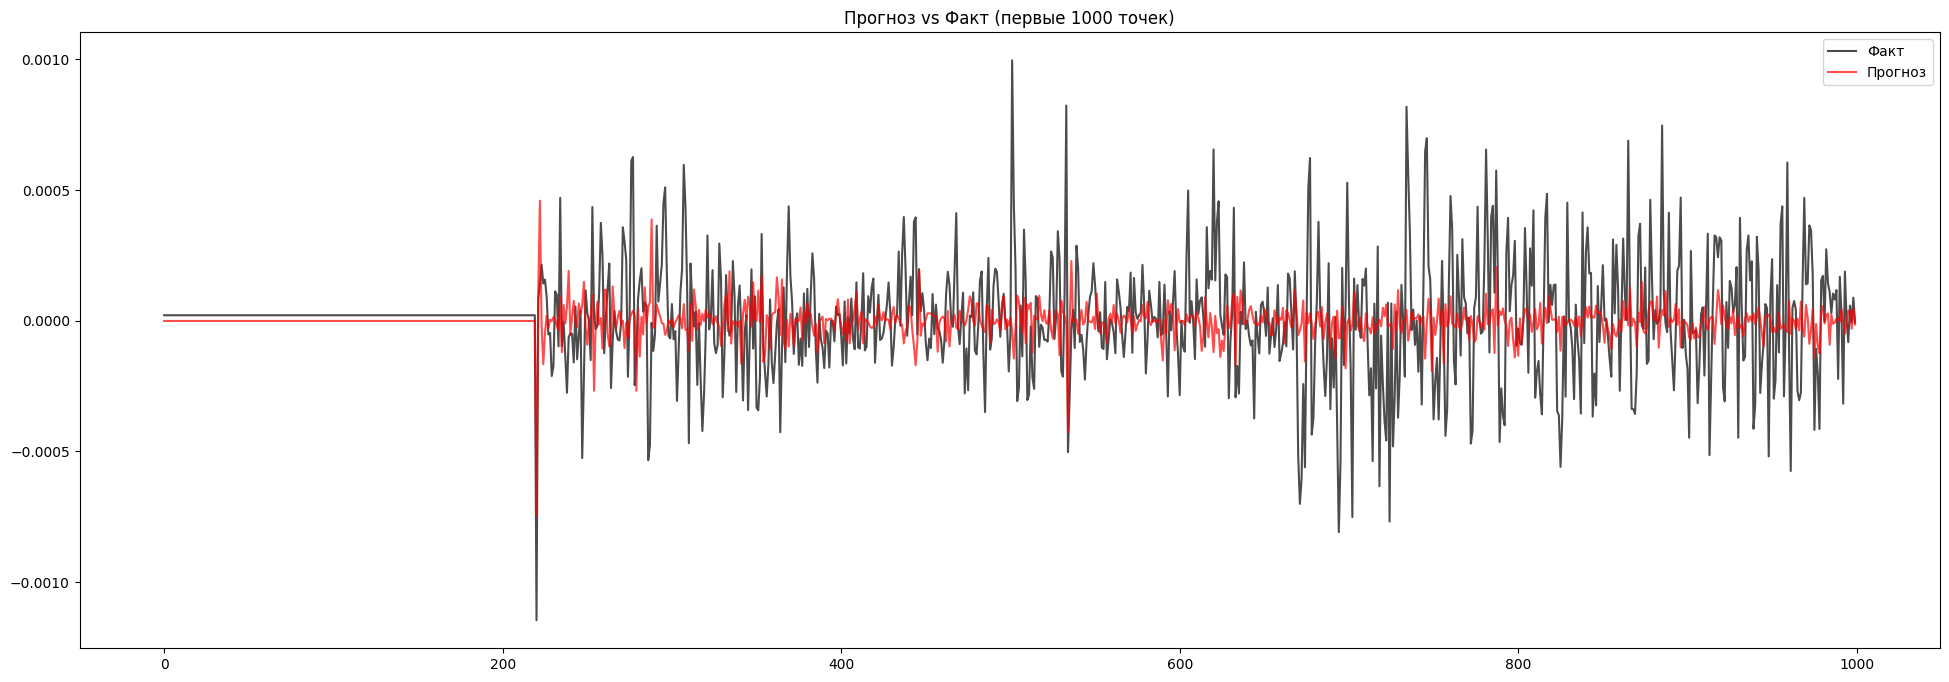

In [6]:
from src.mlcore.evaluation import evaluate_regression_model

y_mid_pred = mid_model.predict(X_test)

evaluate_regression_model(
    y_test=y_mid_test,
    y_pred=y_mid_pred,
    length=1000,
)

### Обучаем spread model

In [7]:
from src.mlcore.train import train_regression_model

spread_model = train_regression_model(
    X_train=X_train,
    y_train=y_spread_train,
    X_test=X_test,
    y_test=y_spread_test,
    n_estimators=5000,
    objective='reg:squaredlogerror',
    model_name="model_spread",
    max_depth=6,
)

Обучение модели...
[0]	validation_0-rmse:0.00022
[50]	validation_0-rmse:0.00019
[100]	validation_0-rmse:0.00018
[150]	validation_0-rmse:0.00017
[200]	validation_0-rmse:0.00017
[250]	validation_0-rmse:0.00017
[300]	validation_0-rmse:0.00017
[350]	validation_0-rmse:0.00017
[400]	validation_0-rmse:0.00017
[450]	validation_0-rmse:0.00017
[500]	validation_0-rmse:0.00017
[550]	validation_0-rmse:0.00017
[600]	validation_0-rmse:0.00017
[650]	validation_0-rmse:0.00017
[700]	validation_0-rmse:0.00017
[750]	validation_0-rmse:0.00017
[800]	validation_0-rmse:0.00017
[850]	validation_0-rmse:0.00017
[880]	validation_0-rmse:0.00017
Модель сохранена в директорию: models/model_spread.json


MAE                      : 0.000113
RMSE                     : 0.000169
R²                       : 0.396433
MAE / mean|Δ|            : 0.531071
RMSE / RMSE_base         : 0.555014
mean|Δ| (target)         : 0.000213

------------------------------------------------------------
Directional Accuracy     : 0.931717
Target Pos Ratio         : 0.931717
Profit Factor            : 35296158492.077438
Avg Gain (correct)       : 0.000229
Avg Loss (incorrect)     : 0.000000

------------------------------------------------------------
Binomial p-value (vs 50%)     : 0.000000
Directional Acc 95% CI        : (0.9304, 0.9329)
Is Significant (α=5%)         : True

📊 Квантильный анализ (топ-3 квантиля по уверенности):
            quantile  confidence  directional_acc  mean_return  n_samples
  (0.00039, 0.00223]    0.000532         0.999940     0.000526      16548
 (0.000294, 0.00039]    0.000335         0.998973     0.000331      16547
(0.000244, 0.000294]    0.000268         0.996374     0.000268    

/Users/honeysuckle/dev/AlgoTradingSystem_c1/src/mlcore/evaluation.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for q, group in df.groupby('quantile'):


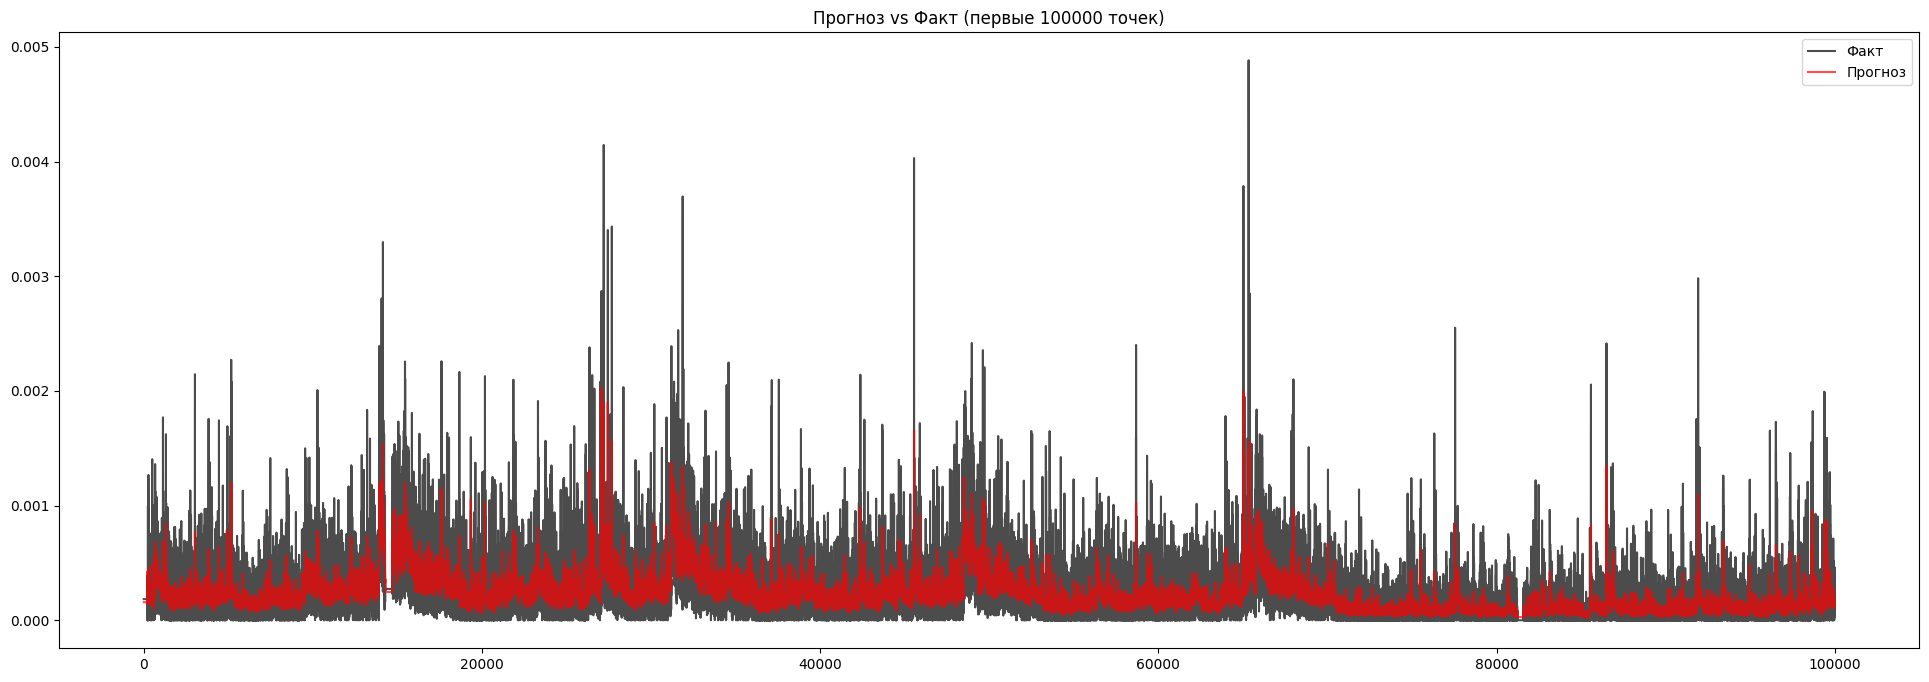

In [8]:
from src.mlcore.evaluation import evaluate_regression_model

y_spread_pred = spread_model.predict(X_test)

evaluate_regression_model(
    y_test=y_spread_test,
    y_pred=y_spread_pred,
    length=100000,
)